# Plotting

This notebook only reads generated experiment records and creates publication-ready figures. The first figure compares ground truth and forecast values for price, PV, and load.

In [18]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

root = Path.cwd().resolve()
while not (root / "notebooks" / "record").exists():
    if root == root.parent:
        raise FileNotFoundError("Cannot locate repository root containing notebooks/record.")
    root = root.parent

forecast_record_dir = root / "notebooks" / "record" / "forecast" / "lstm"
predictions_path = forecast_record_dir / "predictions.parquet"

plot_start = None
plot_end = None


In [19]:
if not predictions_path.exists():
    raise FileNotFoundError(f"Missing forecast prediction record: {predictions_path}")

predictions_df = pd.read_parquet(predictions_path).copy()
required_columns = {"timestamp", "signal_name", "series_name", "target", "prediction"}
missing_columns = sorted(required_columns - set(predictions_df.columns))
if missing_columns:
    raise ValueError(f"predictions.parquet missing required columns: {missing_columns}")

timestamp_index = pd.DatetimeIndex(predictions_df["timestamp"])
if timestamp_index.tz is not None:
    timestamp_index = timestamp_index.tz_localize(None)
predictions_df["timestamp"] = timestamp_index

if plot_start is not None:
    predictions_df = predictions_df.loc[predictions_df["timestamp"] >= pd.Timestamp(plot_start)]
if plot_end is not None:
    predictions_df = predictions_df.loc[predictions_df["timestamp"] <= pd.Timestamp(plot_end)]
if predictions_df.empty:
    raise ValueError("No prediction rows remain after applying plot_start/plot_end.")

display(
    predictions_df.groupby("signal_name", as_index=False).agg(
        rows=("signal_name", "size"),
        series_count=("series_name", "nunique"),
        start=("timestamp", "min"),
        end=("timestamp", "max"),
        mae=("abs_error", "mean"),
    )
)


,signal_name,rows,series_count,start,end,mae
0,load,4320,3,2020-04-01,2020-04-15 23:45:00,9.756691
1,pv,4320,3,2020-04-01,2020-04-15 23:45:00,0.483938
2,wholesale_price,1440,1,2020-04-01,2020-04-15 23:45:00,0.021179


## Figure 1: Price, PV, and Load Forecast Comparison

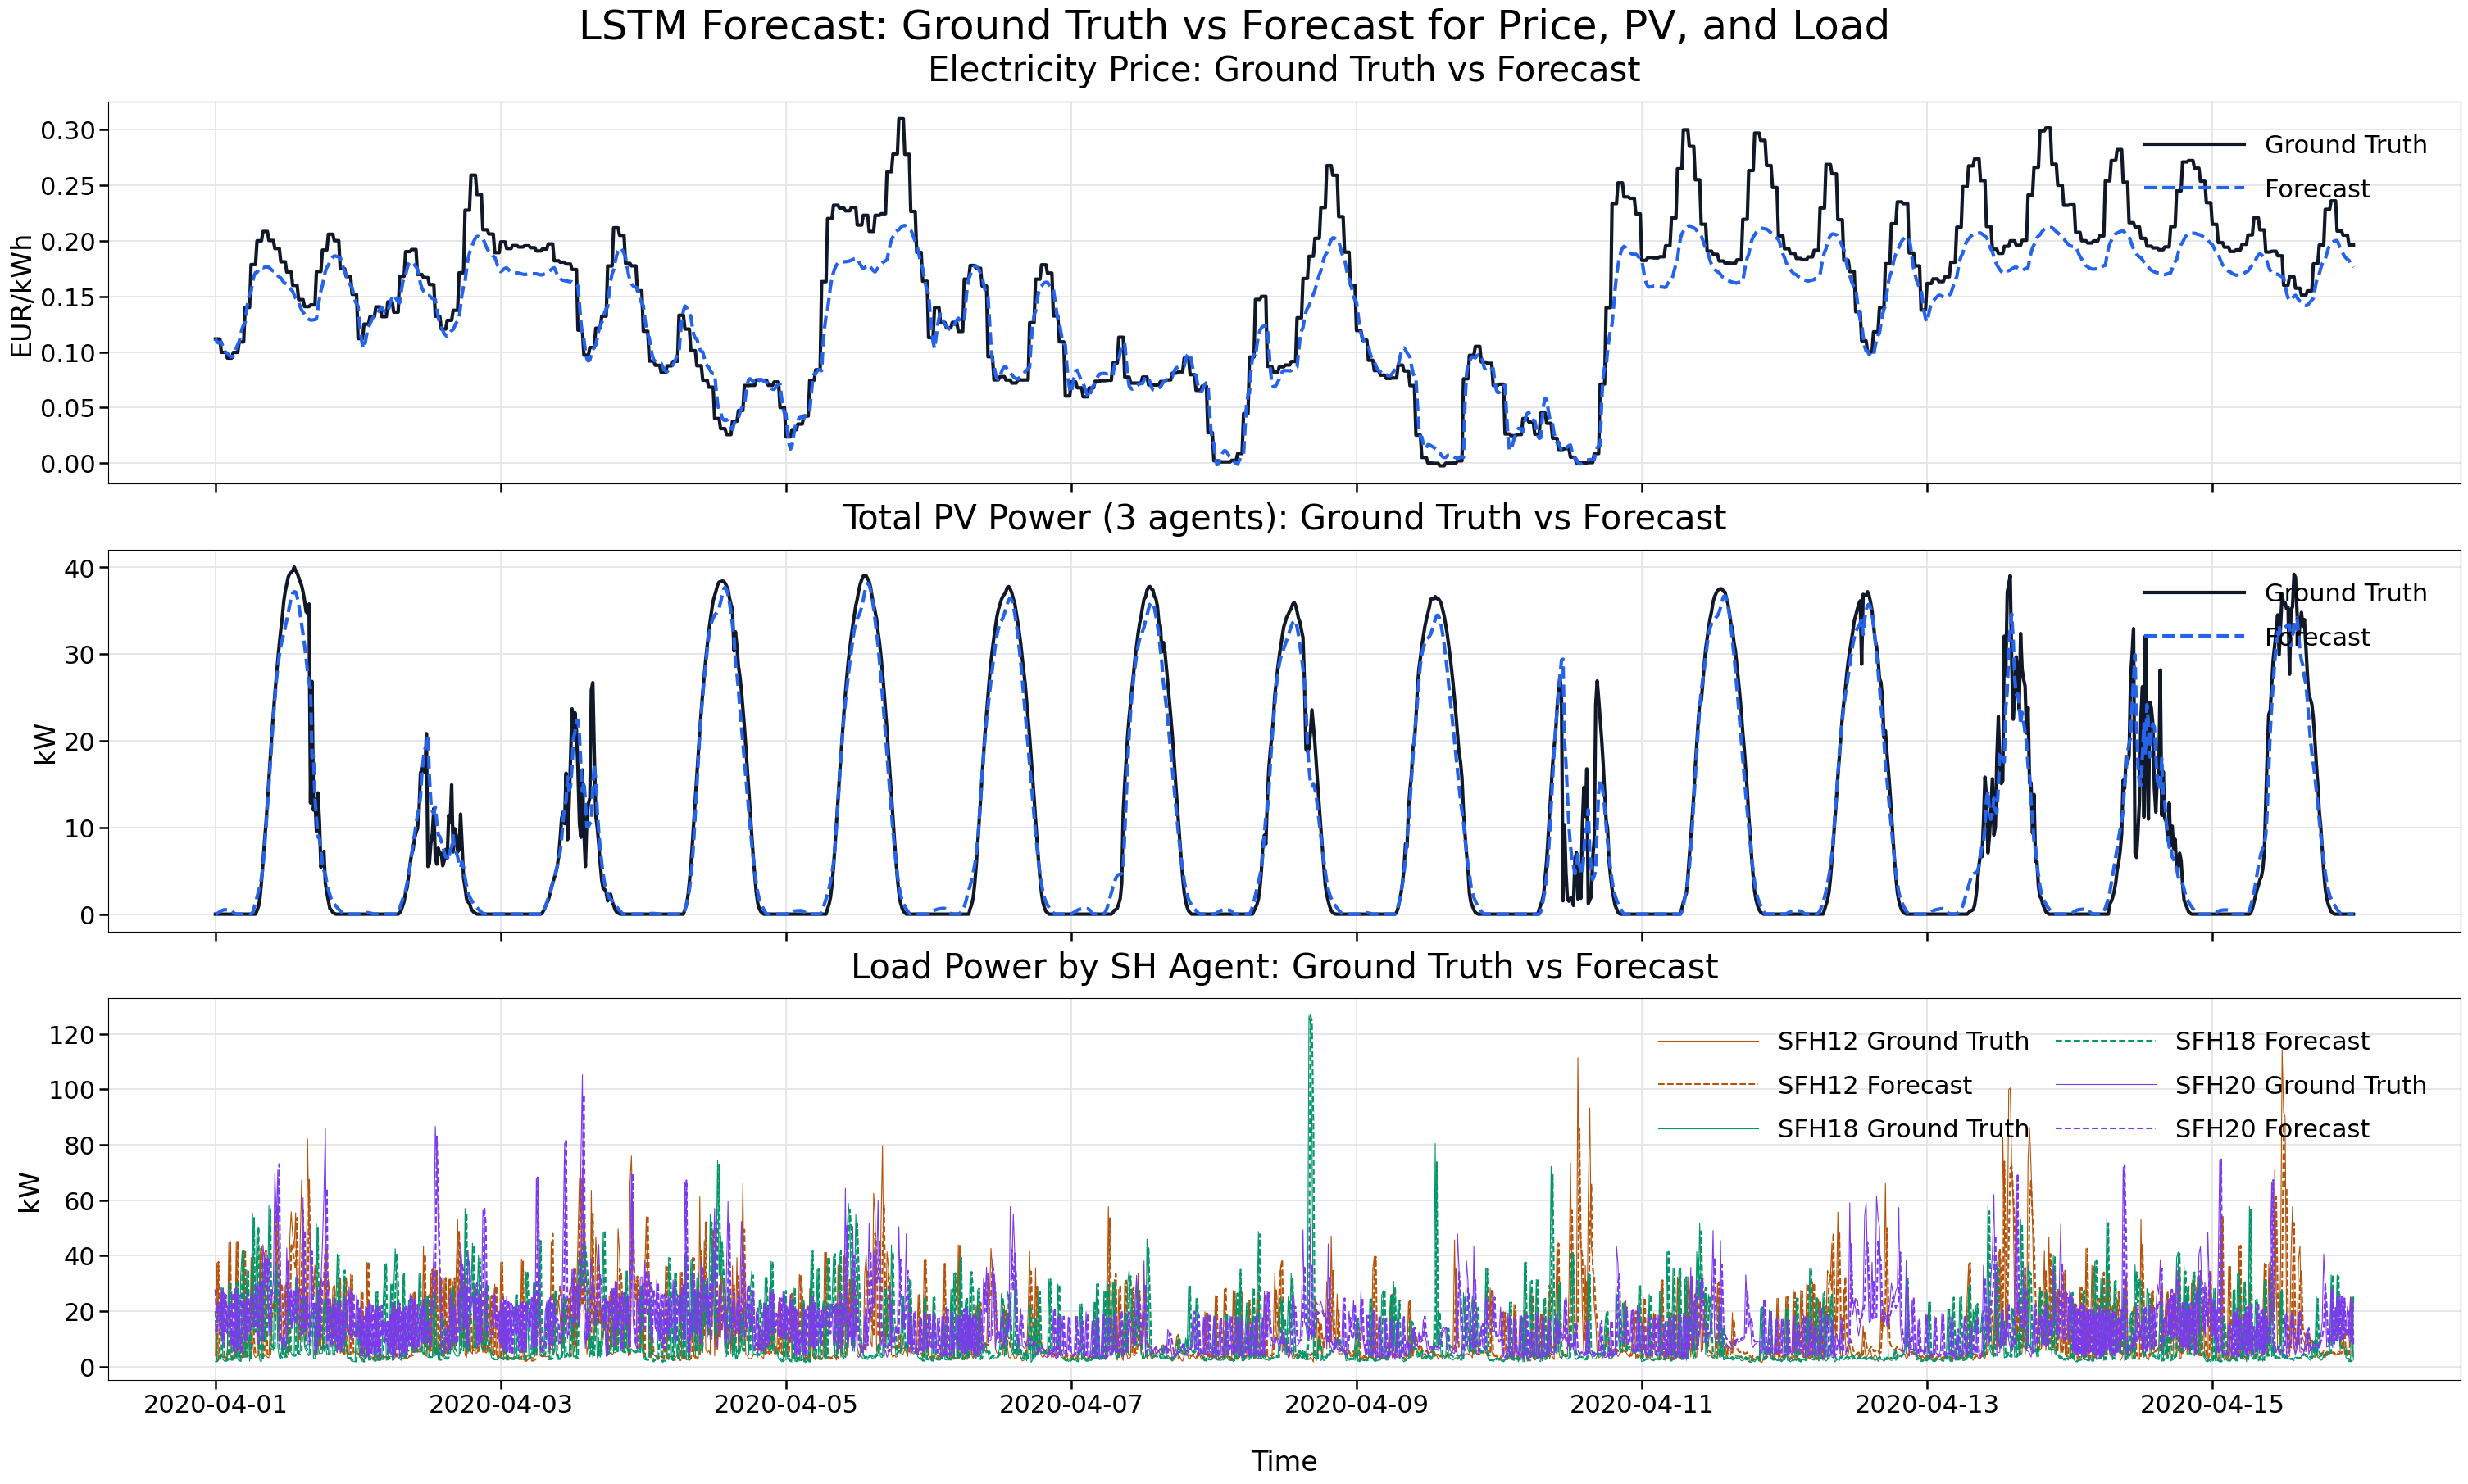

In [24]:
def aggregate_signal(frame: pd.DataFrame, signal_name: str, *, aggregation: str, expected_series_count: int | None = None) -> pd.DataFrame:
    signal_df = frame.loc[frame["signal_name"] == signal_name]
    if signal_df.empty:
        raise ValueError(f"No rows found for signal_name={signal_name!r}.")
    series_names = sorted(signal_df["series_name"].unique().tolist())
    if expected_series_count is not None and len(series_names) != expected_series_count:
        raise ValueError(f"Expected {expected_series_count} series for signal_name={signal_name!r}, got {len(series_names)}: {series_names}")
    pivot = signal_df.pivot_table(index="timestamp", columns="series_name", values=["target", "prediction"], aggfunc="mean").sort_index()
    if aggregation == "sum":
        target = pivot["target"].sum(axis=1)
        prediction = pivot["prediction"].sum(axis=1)
    elif aggregation == "mean":
        target = pivot["target"].mean(axis=1)
        prediction = pivot["prediction"].mean(axis=1)
    else:
        raise ValueError(f"Unknown aggregation={aggregation!r}.")
    grouped = pd.DataFrame({"timestamp": pivot.index, "target": target.to_numpy(), "prediction": prediction.to_numpy()})
    grouped["error"] = grouped["prediction"] - grouped["target"]
    grouped["included_series"] = ", ".join(series_names)
    return grouped.sort_values("timestamp")

def series_signal_curves(frame: pd.DataFrame, signal_name: str, *, expected_series_count: int | None = None) -> dict[str, pd.DataFrame]:
    signal_df = frame.loc[frame["signal_name"] == signal_name]
    if signal_df.empty:
        raise ValueError(f"No rows found for signal_name={signal_name!r}.")
    series_names = sorted(signal_df["series_name"].unique().tolist())
    if expected_series_count is not None and len(series_names) != expected_series_count:
        raise ValueError(f"Expected {expected_series_count} series for signal_name={signal_name!r}, got {len(series_names)}: {series_names}")
    pivot = signal_df.pivot_table(index="timestamp", columns="series_name", values=["target", "prediction"], aggfunc="mean").sort_index()
    return {
        series_name: pd.DataFrame({"timestamp": pivot.index, "target": pivot[("target", series_name)].to_numpy(), "prediction": pivot[("prediction", series_name)].to_numpy()}).sort_values("timestamp")
        for series_name in series_names
    }

plot_specs = [
    {"title": "Electricity Price", "signal_name": "wholesale_price", "aggregation": "mean", "expected_series_count": 1, "ylabel": "EUR/kWh"},
    {"title": "Total PV Power (3 agents)", "signal_name": "pv", "aggregation": "sum", "expected_series_count": 3, "ylabel": "kW"},
    {"title": "Load Power by SH Agent", "signal_name": "load", "aggregation": "series", "expected_series_count": 3, "ylabel": "kW"},
]

plt.rcParams.update({"font.size": 22, "axes.titlesize": 30, "axes.labelsize": 24, "legend.fontsize": 22, "xtick.labelsize": 22, "ytick.labelsize": 22})
fig, axes = plt.subplots(3, 1, figsize=(30, 18), sharex=True, constrained_layout=True)
series_colors = ["#B45309", "#059669", "#7C3AED"]
for ax, spec in zip(axes, plot_specs, strict=True):
    if spec["aggregation"] == "series":
        curves = series_signal_curves(predictions_df, spec["signal_name"], expected_series_count=spec["expected_series_count"])
        for color, (series_name, curve) in zip(series_colors, curves.items(), strict=True):
            label_name = series_name.replace("load_", "").replace("pv_", "")
            ax.plot(curve["timestamp"], curve["target"], color=color, linewidth=0.8, label=f"{label_name} Ground Truth")
            ax.plot(curve["timestamp"], curve["prediction"], color=color, linewidth=1.5, linestyle="--", label=f"{label_name} Forecast")
    else:
        curve = aggregate_signal(predictions_df, spec["signal_name"], aggregation=spec["aggregation"], expected_series_count=spec["expected_series_count"])
        ax.plot(curve["timestamp"], curve["target"], color="#111827", linewidth=3, label="Ground Truth")
        ax.plot(curve["timestamp"], curve["prediction"], color="#2563EB", linewidth=3, linestyle="--", label="Forecast")
    ax.set_title(f"{spec['title']}: Ground Truth vs Forecast", loc="center", pad=18)
    ax.set_ylabel(spec["ylabel"])
    ax.grid(True, color="#E5E7EB", linewidth=1.4)
    ax.tick_params(axis="both", which="major", labelsize=22, width=1.8, length=8)
    legend_kwargs = {"loc": "upper right", "frameon": False, "handlelength": 4.0, "borderpad": 0.8, "labelspacing": 0.8}
    if spec["aggregation"] == "series":
        legend_kwargs.update({"ncol": 2, "columnspacing": 1.0})
    ax.legend(**legend_kwargs)

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=10))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n"))
fig.suptitle("LSTM Forecast: Ground Truth vs Forecast for Price, PV, and Load", fontsize=36, x=0.5, ha="center")
plt.show()
